# N-pulse LMT sequence -- shot-by-shot filmstrip

Same large-momentum-transfer sequence as `n_pulse_lmt_sequence.ipynb` (a $\pi/2$ beam splitter, $N$ accelerating and $N$ decelerating $\pi$ pulses on the top arm, a $\pi$ mirror, the same $N+N$ pulses on the bottom arm, a final $\pi/2$ recombiner, and a trailing free fall) but run on a thermal velocity ensemble so the synthetic camera has something to image.

Each cell below renders a per-event filmstrip via `lmt_sim.imaging.plot_filmstrip`. `LMT_N` controls how many pulses per arm; the call cells sweep the mirror phase $\phi$ across $[0, 2\pi]$.

In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
from scipy import constants

import lmt_sim.lmt_sequence as seq
from lmt_sim.lmt_simulation import RABI_FREQ, T_PI, RECOIL_FREQUENCY_HZ
from lmt_sim.imaging import plot_filmstrip

%matplotlib inline

In [3]:
# Thermal ensemble (Maxwell-Boltzmann, 1D z-velocity).
# Smaller than the MZ notebook because each LMT shot runs ~20 pulses per atom.
N_ATOMS = 50
TEMPERATURE = 200e-9
MASS_ATOM = 87 * constants.atomic_mass
sigma_v = np.sqrt(constants.k * TEMPERATURE / MASS_ATOM)
velocities = np.random.default_rng(0).normal(0, sigma_v, size=N_ATOMS)

LMT_N = 4  # pulses per arm

In [4]:
def build_lmt_sequence(N, phi):
    """Same sequence builder as notebooks/n_pulse_lmt_sequence.ipynb cell 5.

    Pi/2 beam splitter, N pi pulses accelerating then decelerating the top arm,
    pi mirror, N pi pulses accelerating then decelerating the bottom arm, pi/2
    recombiner with phase 4*phi, plus a trailing freefall so the clouds separate
    visibly in the final shot.
    """
    s = []

    s.append(seq.Pulse(
        k=+1, detuning_hz=+1 * RECOIL_FREQUENCY_HZ, phi=0.0,
        label='BS pi/2', rabi_frequency=RABI_FREQ, duration=T_PI / 2,
    ))

    # (k, detuning_multiplier) for the i-th pulse in an arm: (-1,-3),(+1,+5),(-1,-7),...
    kicks = [
        ((-1 if i % 2 == 0 else +1),
         (-1 if i % 2 == 0 else +1) * (2 * (i + 1) + 1))
        for i in range(N)
    ]

    for i, (k, d) in enumerate(kicks, start=1):
        s.append(seq.Pulse(k=k, detuning_hz=d * RECOIL_FREQUENCY_HZ, phi=0.0,
                           label=f'top accel {i}', rabi_frequency=RABI_FREQ, duration=T_PI))
    for i, (k, d) in enumerate(reversed(kicks), start=1):
        s.append(seq.Pulse(k=k, detuning_hz=d * RECOIL_FREQUENCY_HZ, phi=0.0,
                           label=f'top decel {i}', rabi_frequency=RABI_FREQ, duration=T_PI))

    s.append(seq.Pulse(
        k=+1, detuning_hz=+1 * RECOIL_FREQUENCY_HZ, phi=phi,
        label='mirror pi', rabi_frequency=RABI_FREQ, duration=T_PI,
    ))

    for i, (k, d) in enumerate(kicks, start=1):
        s.append(seq.Pulse(k=k, detuning_hz=d * RECOIL_FREQUENCY_HZ, phi=phi,
                           label=f'bottom accel {i}', rabi_frequency=RABI_FREQ, duration=T_PI))
    for i, (k, d) in enumerate(reversed(kicks), start=1):
        s.append(seq.Pulse(k=k, detuning_hz=d * RECOIL_FREQUENCY_HZ, phi=phi,
                           label=f'bottom decel {i}', rabi_frequency=RABI_FREQ, duration=T_PI))

    s.append(seq.Pulse(
        k=+1, detuning_hz=+1 * RECOIL_FREQUENCY_HZ, phi=4 * phi,
        label='BS pi/2 final', rabi_frequency=RABI_FREQ, duration=T_PI / 2,
    ))

    # Trailing freefall so the m-state separation is visible in the final shot.
    s.append(seq.Freefall(duration=T_PI, label='freefall'))
    return s


def plot_lmt_filmstrip(phi, N=LMT_N):
    sequence = build_lmt_sequence(N=N, phi=phi)
    return plot_filmstrip(
        sequence, velocities,
        title=f'LMT $N={N}$ filmstrip at $\\phi = {phi / np.pi:.3f}\\pi$ (each panel autoscaled)',
        desc=f'N={N}, phi={phi / np.pi:.3f}pi',
        panel_width=1.6, panel_height=3.2,
        # Lossy threshold: keeps weights to ~0.1% of exact while running ~6x faster.
        # Plenty for visualisation; bump down to 1e-9 if you need exact channel weights.
        discard_threshold=1e-6,
    )

N=4, phi=0.000pi:   0%|          | 0/50 [00:00<?, ?it/s]

N=4, phi=0.000pi:   4%|▍         | 2/50 [00:00<00:03, 15.17it/s]

N=4, phi=0.000pi:   8%|▊         | 4/50 [00:00<00:12,  3.66it/s]

N=4, phi=0.000pi:  10%|█         | 5/50 [00:01<00:12,  3.69it/s]

N=4, phi=0.000pi:  12%|█▏        | 6/50 [00:01<00:11,  3.72it/s]

...

N=4, phi=0.000pi:  94%|█████████▍| 47/50 [00:39<00:04,  1.58s/it]

N=4, phi=0.000pi:  96%|█████████▌| 48/50 [00:40<00:03,  1.63s/it]

N=4, phi=0.000pi:  98%|█████████▊| 49/50 [00:43<00:01,  1.86s/it]

N=4, phi=0.000pi: 100%|██████████| 50/50 [00:46<00:00,  2.17s/it]

N=4, phi=0.000pi: 100%|██████████| 50/50 [00:46<00:00,  1.08it/s]

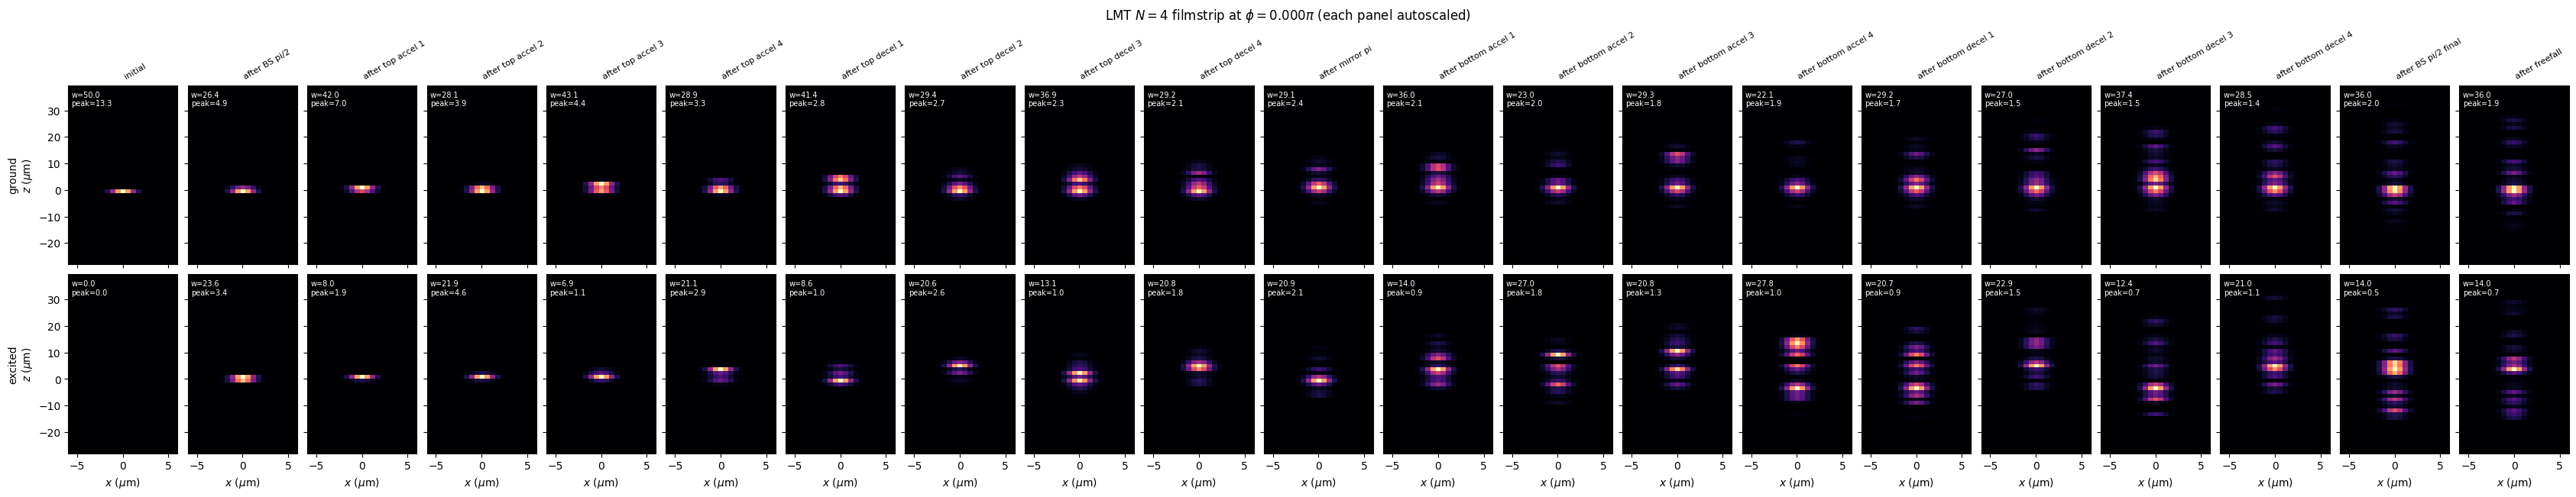

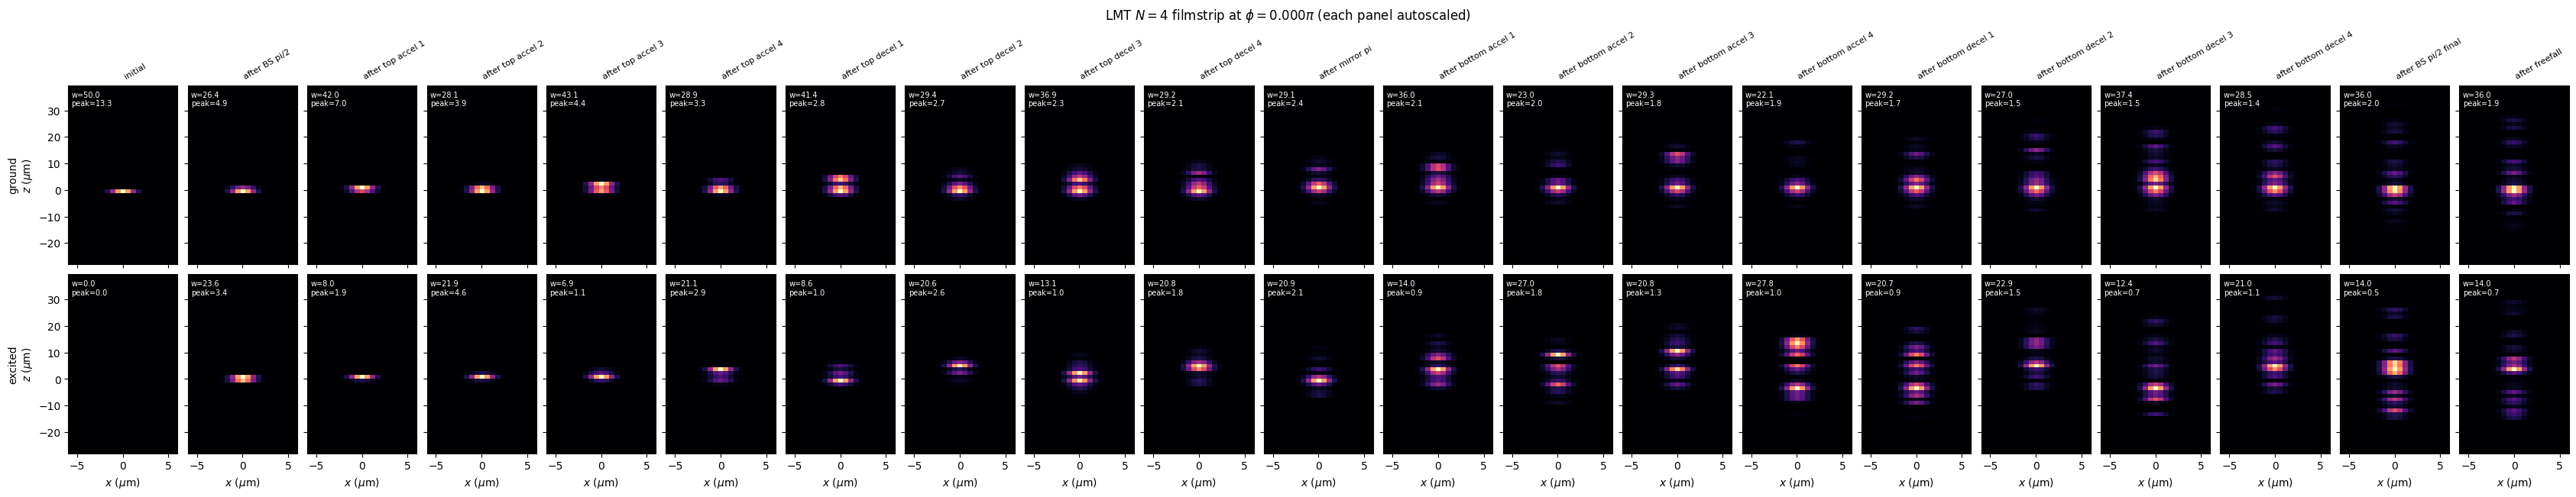

In [5]:
plot_lmt_filmstrip(0.0)

N=4, phi=0.500pi:   0%|          | 0/50 [00:00<?, ?it/s]

N=4, phi=0.500pi:   4%|▍         | 2/50 [00:00<00:03, 15.24it/s]

N=4, phi=0.500pi:   8%|▊         | 4/50 [00:00<00:12,  3.69it/s]

N=4, phi=0.500pi:  10%|█         | 5/50 [00:01<00:12,  3.73it/s]

N=4, phi=0.500pi:  12%|█▏        | 6/50 [00:01<00:11,  3.77it/s]

...

N=4, phi=0.500pi:  94%|█████████▍| 47/50 [00:39<00:04,  1.62s/it]

N=4, phi=0.500pi:  96%|█████████▌| 48/50 [00:41<00:03,  1.67s/it]

N=4, phi=0.500pi:  98%|█████████▊| 49/50 [00:43<00:01,  1.89s/it]

N=4, phi=0.500pi: 100%|██████████| 50/50 [00:46<00:00,  2.21s/it]

N=4, phi=0.500pi: 100%|██████████| 50/50 [00:46<00:00,  1.08it/s]

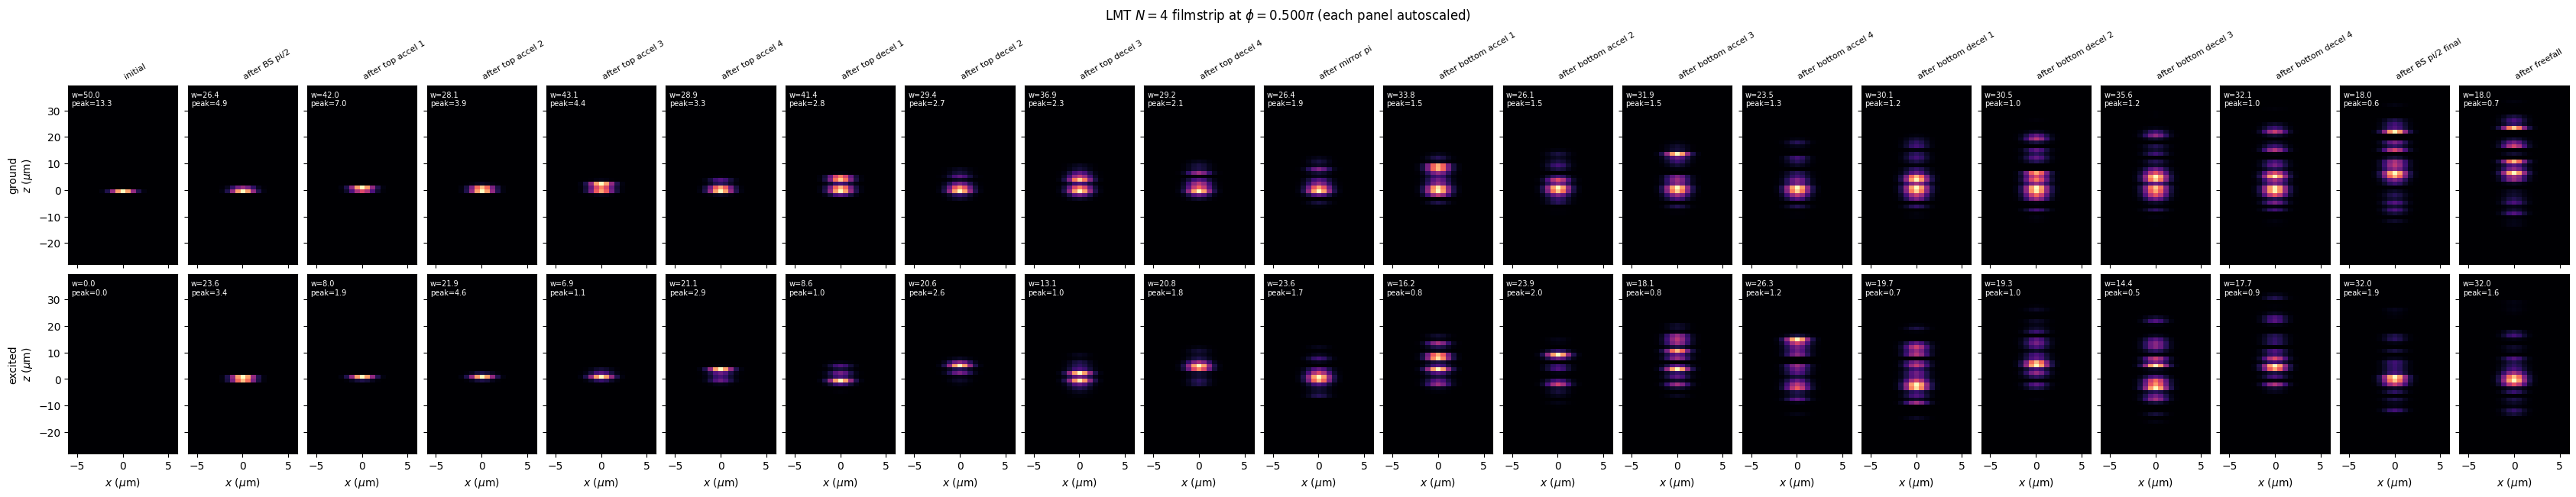

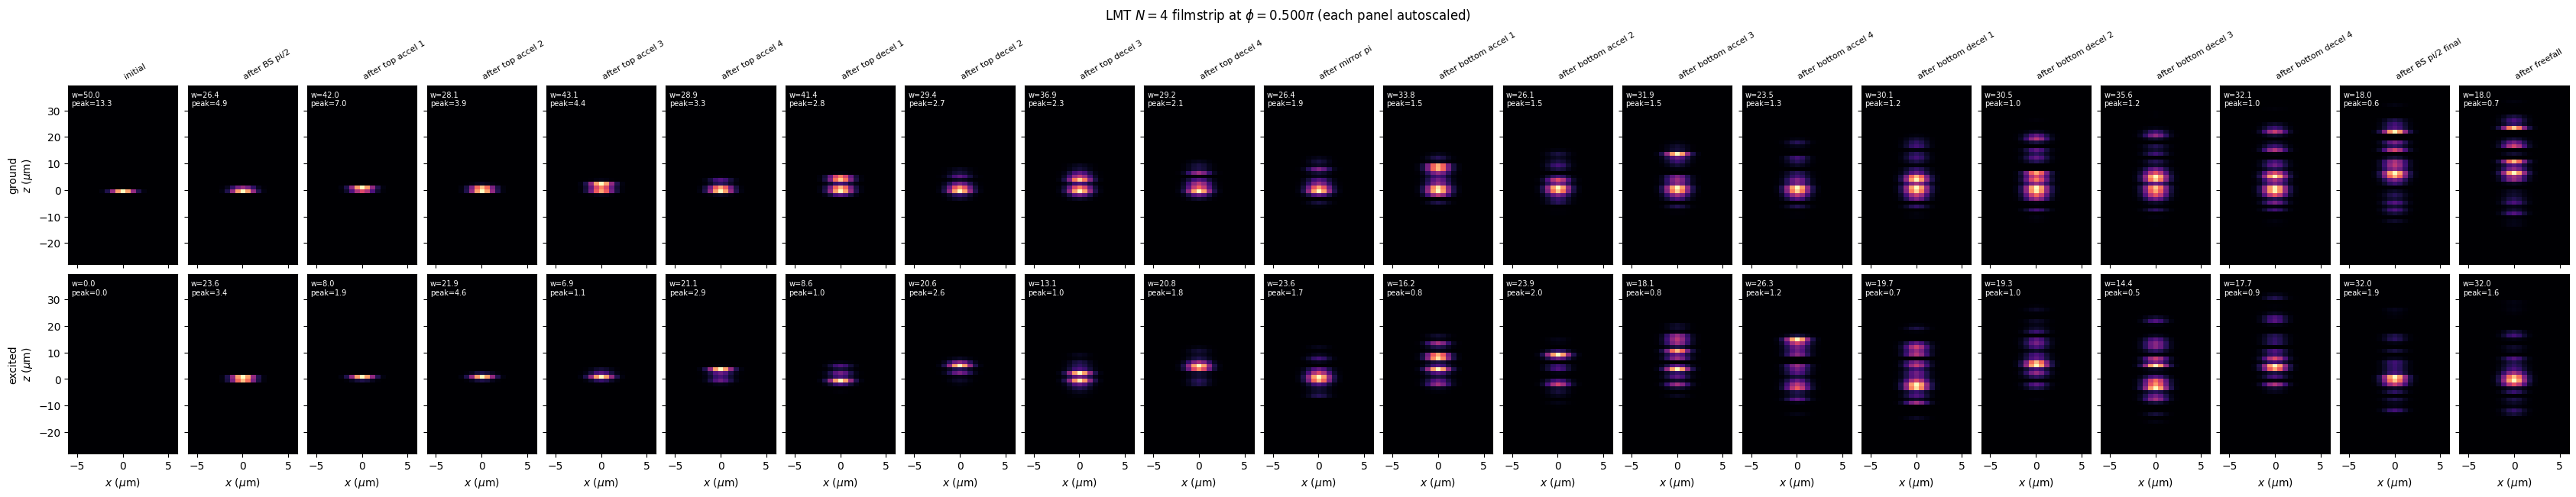

In [6]:
plot_lmt_filmstrip(np.pi / 2)

N=4, phi=1.000pi:   0%|          | 0/50 [00:00<?, ?it/s]

N=4, phi=1.000pi:   4%|▍         | 2/50 [00:00<00:03, 15.17it/s]

N=4, phi=1.000pi:   8%|▊         | 4/50 [00:00<00:12,  3.64it/s]

N=4, phi=1.000pi:  10%|█         | 5/50 [00:01<00:12,  3.62it/s]

N=4, phi=1.000pi:  12%|█▏        | 6/50 [00:01<00:12,  3.63it/s]

...

N=4, phi=1.000pi:  94%|█████████▍| 47/50 [00:39<00:04,  1.61s/it]

N=4, phi=1.000pi:  96%|█████████▌| 48/50 [00:40<00:03,  1.66s/it]

N=4, phi=1.000pi:  98%|█████████▊| 49/50 [00:43<00:01,  1.87s/it]

N=4, phi=1.000pi: 100%|██████████| 50/50 [00:46<00:00,  2.21s/it]

N=4, phi=1.000pi: 100%|██████████| 50/50 [00:46<00:00,  1.08it/s]

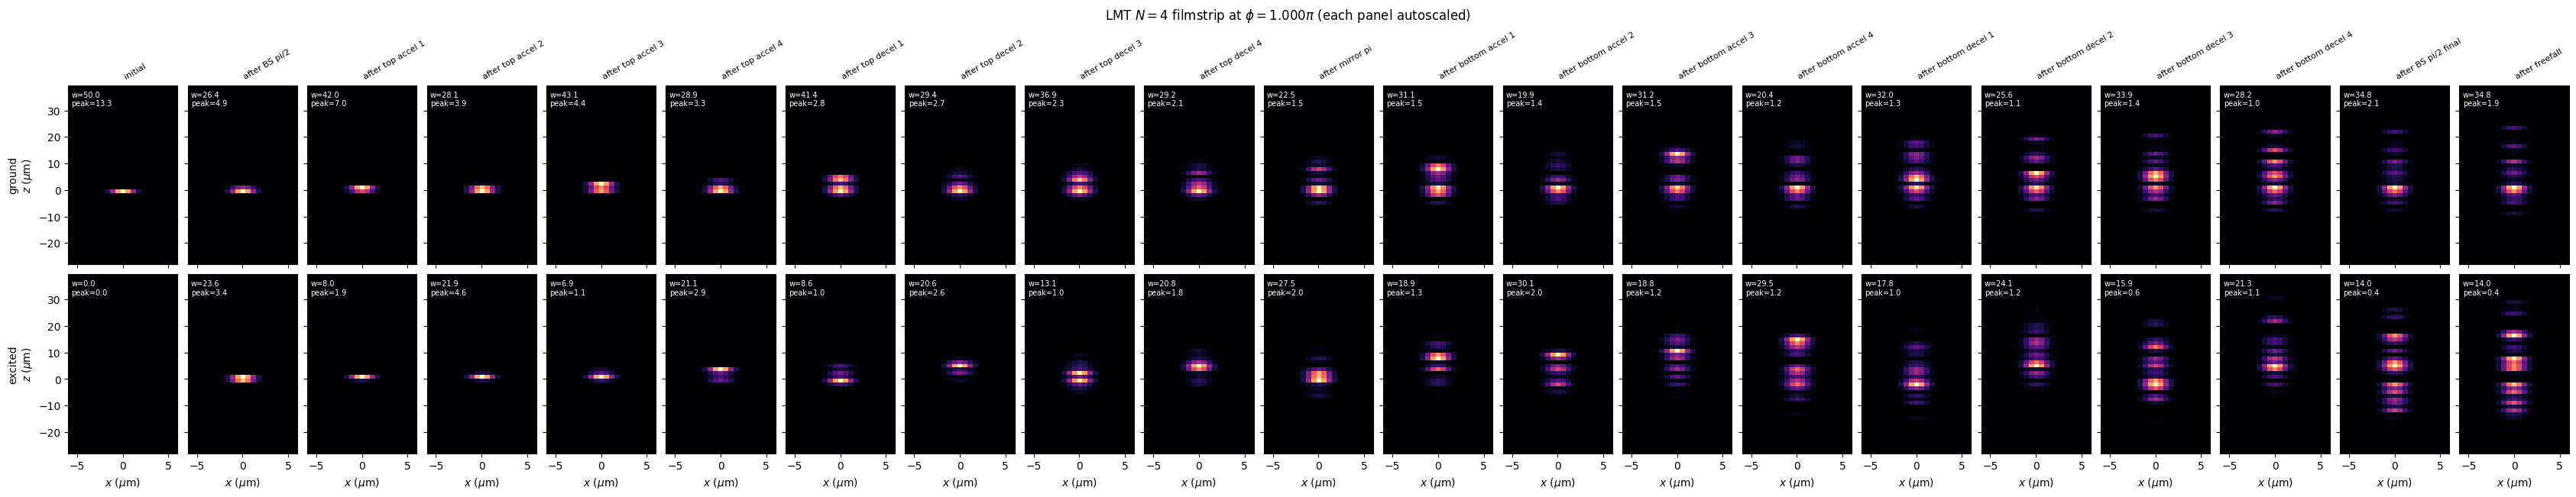

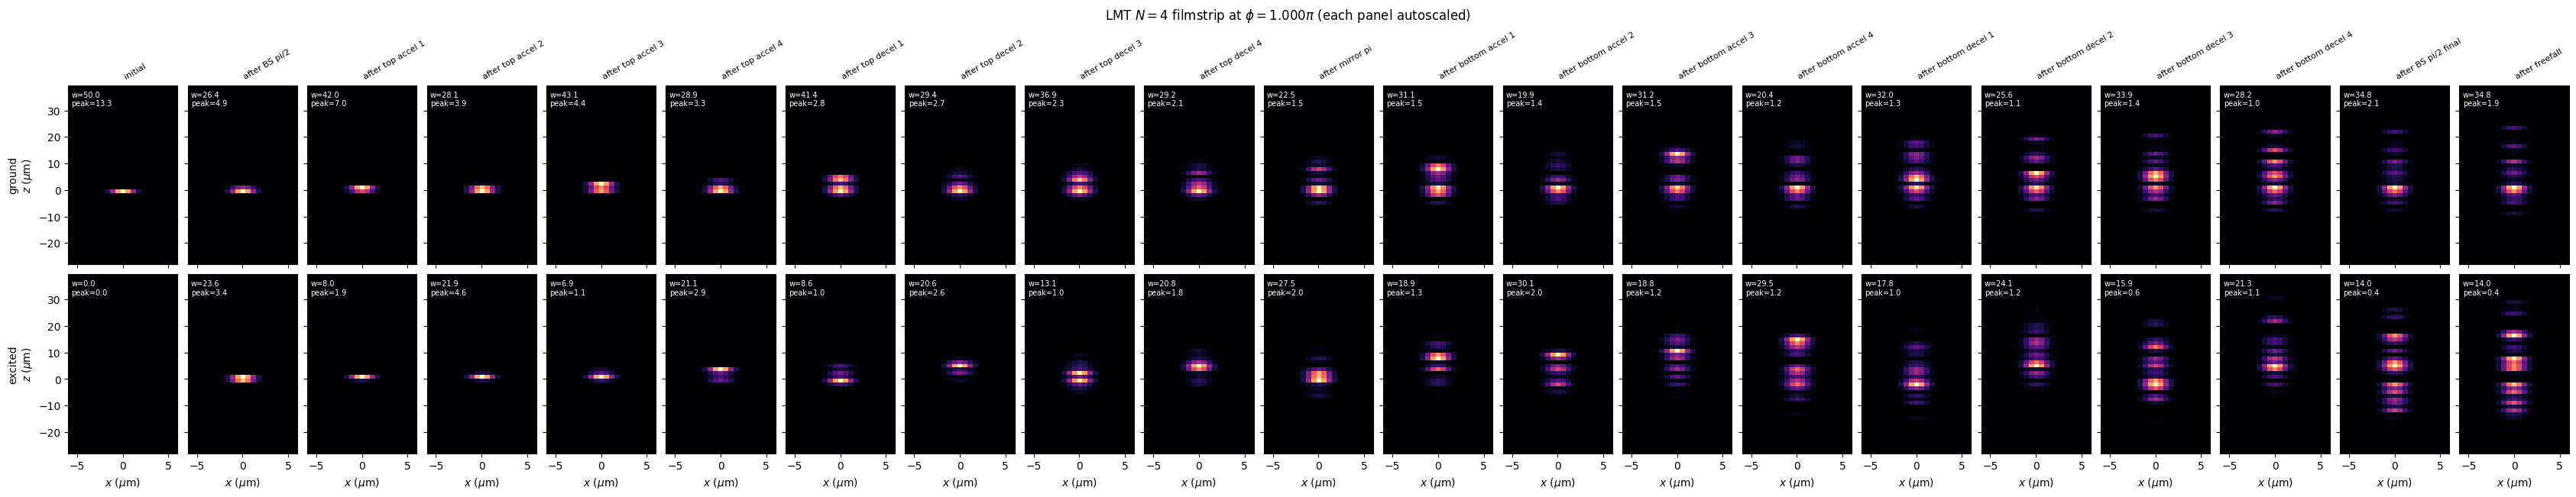

In [7]:
plot_lmt_filmstrip(np.pi)

N=4, phi=1.500pi:   0%|          | 0/50 [00:00<?, ?it/s]

N=4, phi=1.500pi:   4%|▍         | 2/50 [00:00<00:03, 15.25it/s]

N=4, phi=1.500pi:   8%|▊         | 4/50 [00:01<00:13,  3.46it/s]

N=4, phi=1.500pi:  10%|█         | 5/50 [00:01<00:12,  3.57it/s]

N=4, phi=1.500pi:  12%|█▏        | 6/50 [00:01<00:11,  3.67it/s]

...

N=4, phi=1.500pi:  94%|█████████▍| 47/50 [00:39<00:04,  1.62s/it]

N=4, phi=1.500pi:  96%|█████████▌| 48/50 [00:41<00:03,  1.66s/it]

N=4, phi=1.500pi:  98%|█████████▊| 49/50 [00:43<00:01,  1.88s/it]

N=4, phi=1.500pi: 100%|██████████| 50/50 [00:46<00:00,  2.19s/it]

N=4, phi=1.500pi: 100%|██████████| 50/50 [00:46<00:00,  1.07it/s]

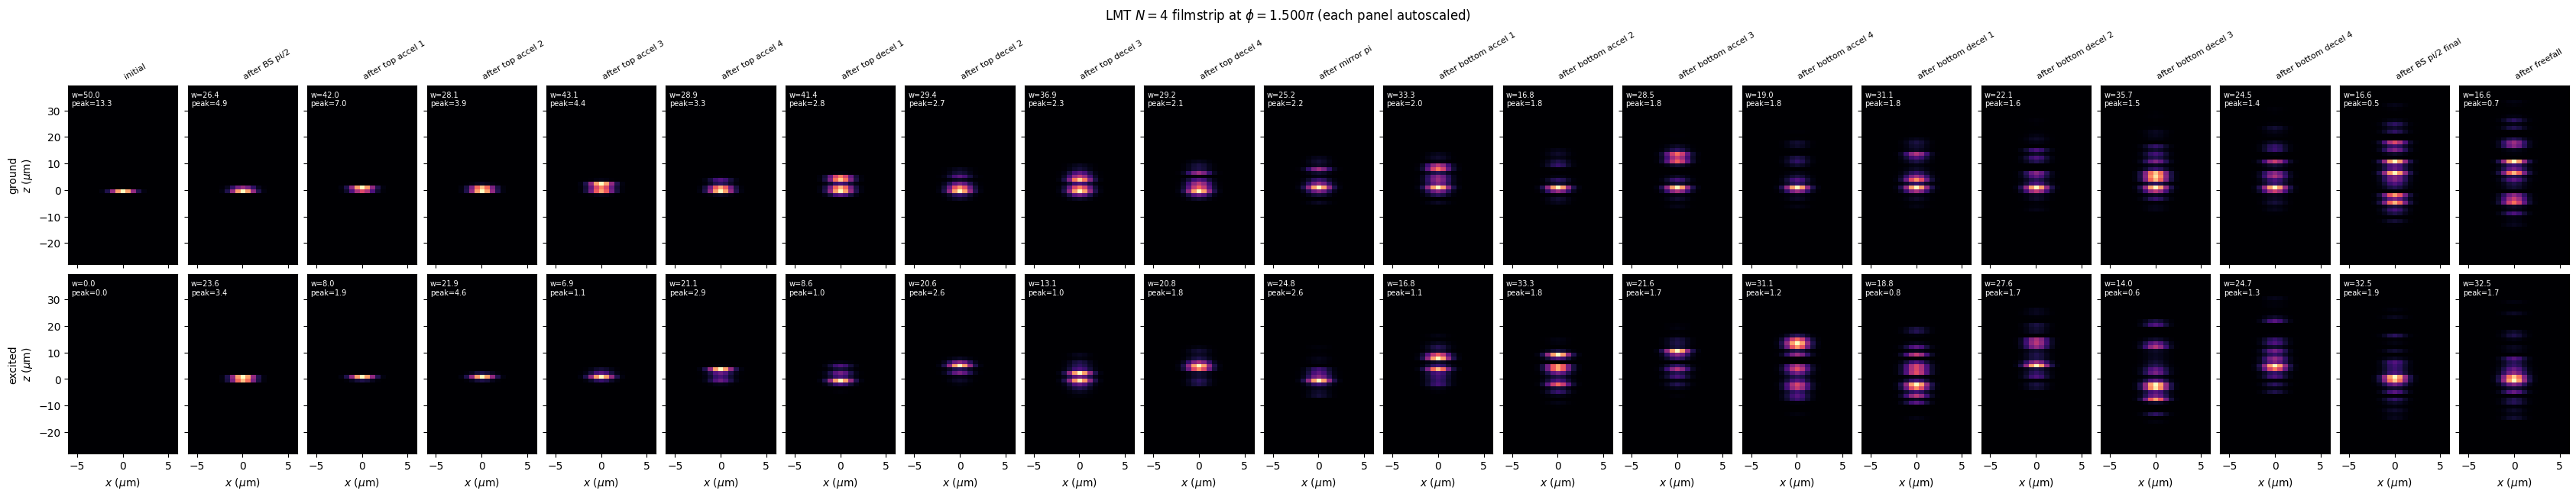

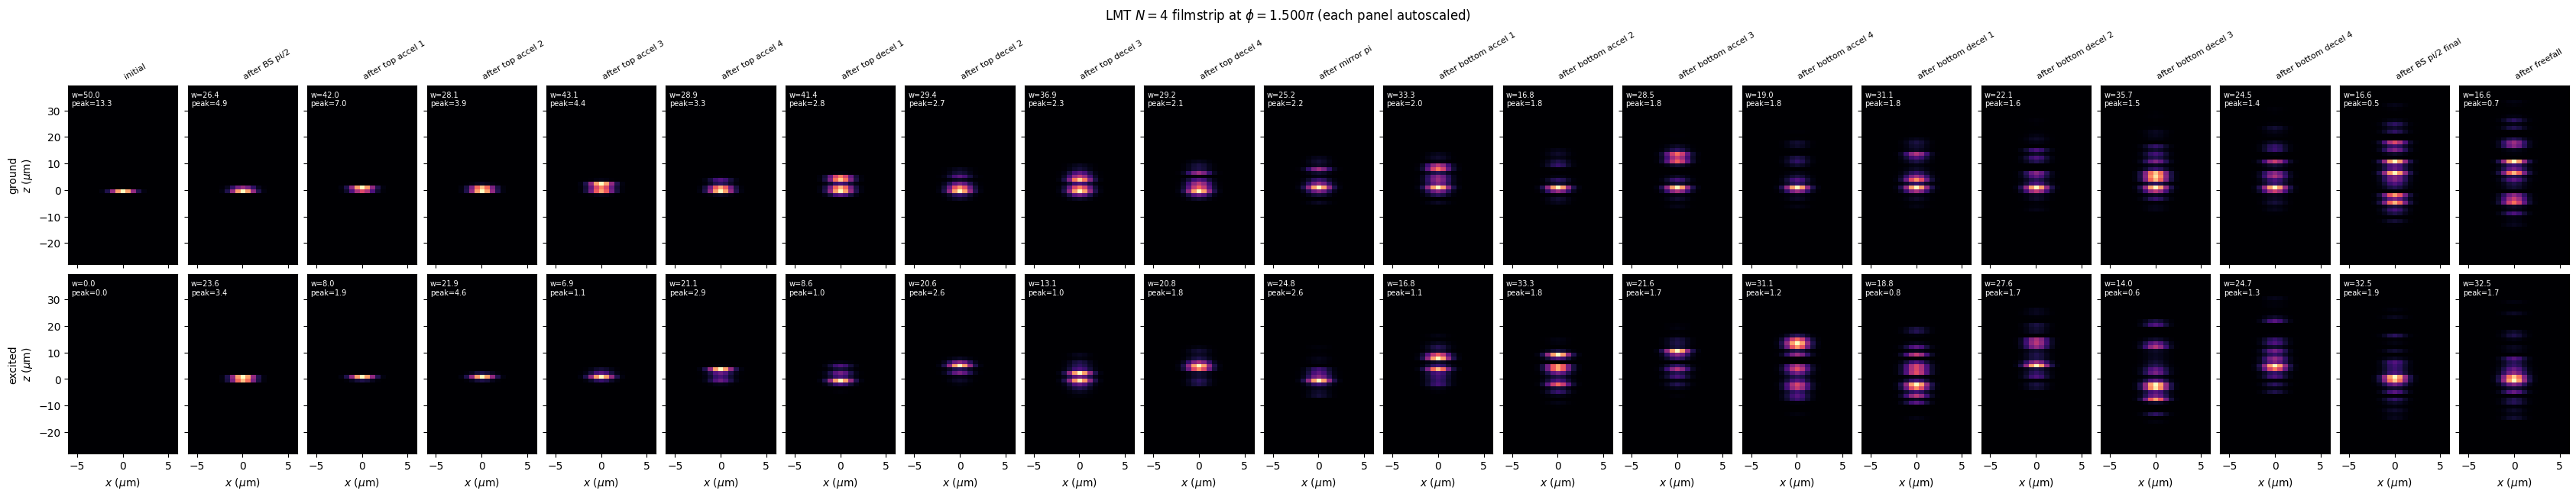

In [8]:
plot_lmt_filmstrip(3 * np.pi / 2)

N=4, phi=2.000pi:   0%|          | 0/50 [00:00<?, ?it/s]

N=4, phi=2.000pi:   4%|▍         | 2/50 [00:00<00:03, 15.22it/s]

N=4, phi=2.000pi:   8%|▊         | 4/50 [00:01<00:13,  3.32it/s]

N=4, phi=2.000pi:  10%|█         | 5/50 [00:01<00:13,  3.43it/s]

N=4, phi=2.000pi:  12%|█▏        | 6/50 [00:01<00:12,  3.54it/s]

...

N=4, phi=2.000pi:  94%|█████████▍| 47/50 [00:39<00:04,  1.65s/it]

N=4, phi=2.000pi:  96%|█████████▌| 48/50 [00:41<00:03,  1.69s/it]

N=4, phi=2.000pi:  98%|█████████▊| 49/50 [00:44<00:01,  1.92s/it]

N=4, phi=2.000pi: 100%|██████████| 50/50 [00:47<00:00,  2.24s/it]

N=4, phi=2.000pi: 100%|██████████| 50/50 [00:47<00:00,  1.06it/s]

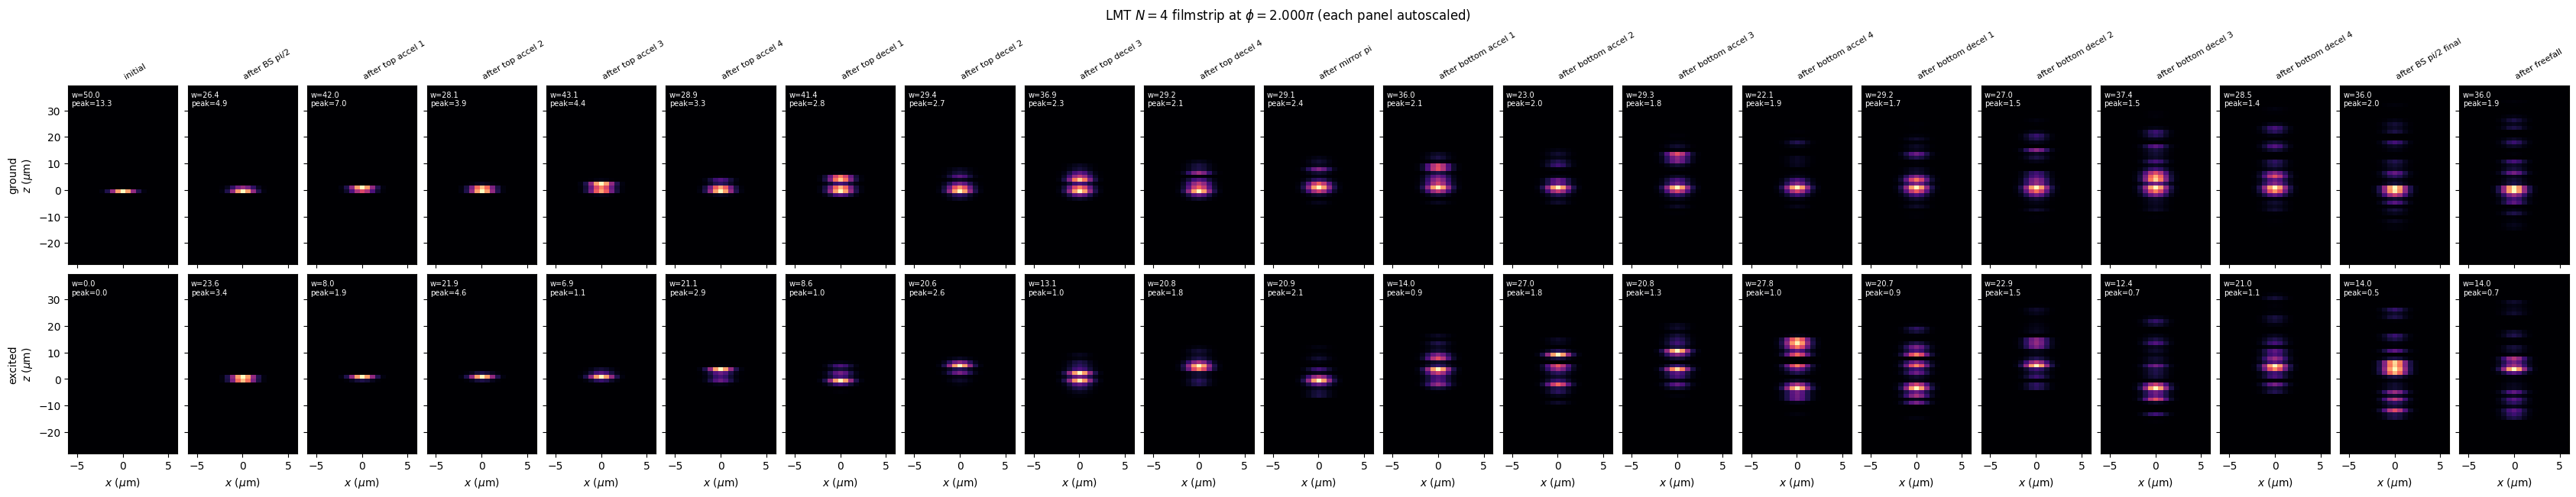

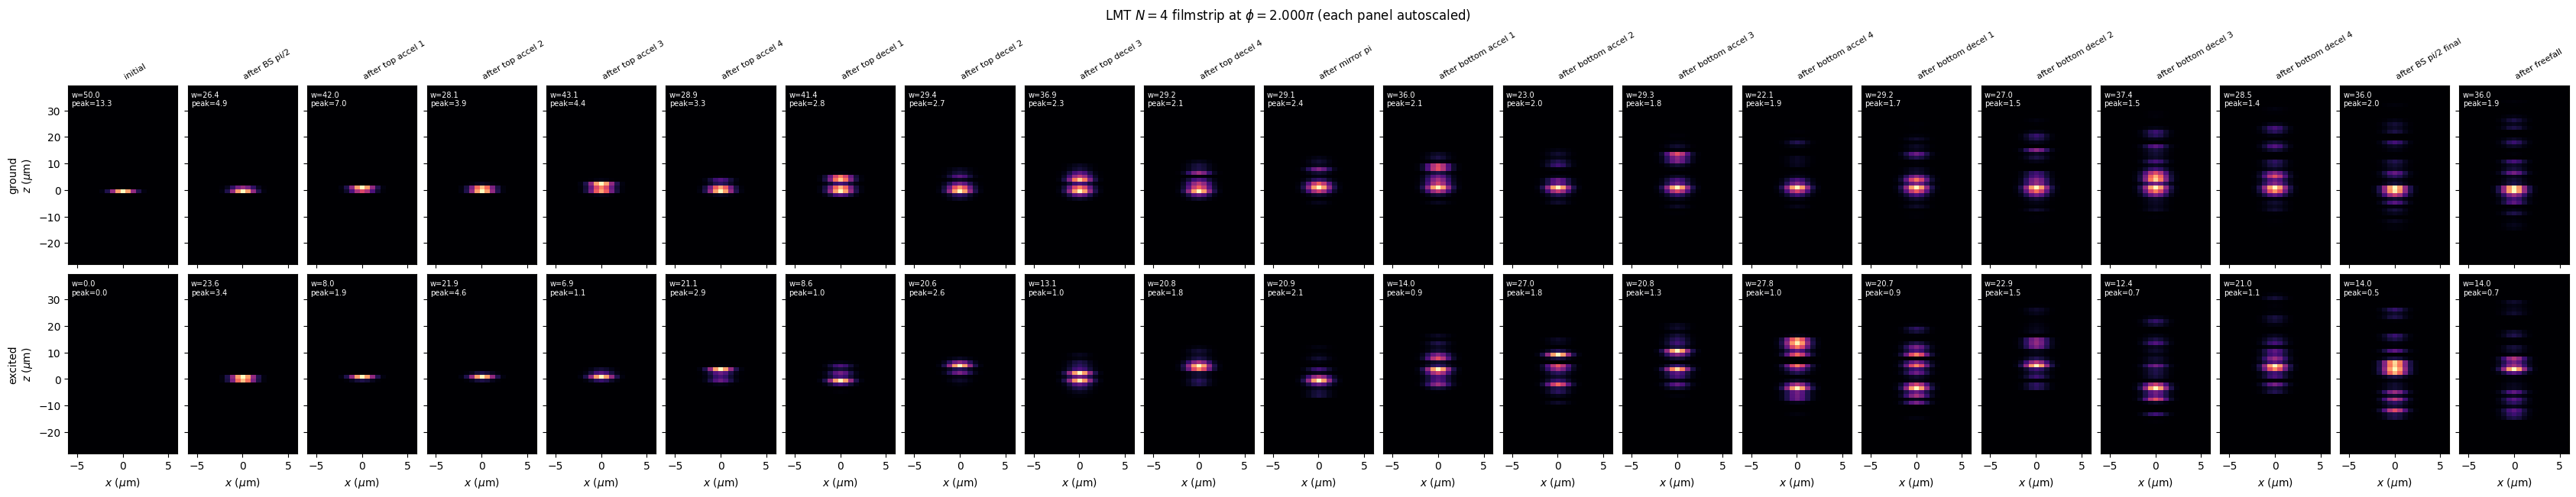

In [9]:
plot_lmt_filmstrip(2 * np.pi)